In [33]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for plotting
import matplotlib.cm as cm # for color maps in plots
from sklearn.feature_extraction.text import TfidfVectorizer # for converting text to TF-IDF features
from sklearn.decomposition import TruncatedSVD, PCA # for dimensionality reduction
from sklearn.preprocessing import normalize # for normalizing data


In [34]:
# We will load preprocessed data from the pickle file created in preprocessing.py
df = pd.read_pickle("../data_preprocessed.pkl")
print(f"Loaded preprocessed data with {len(df)} papers.") # printing the number of papers in the preprocessed DataFrame to confirm it loaded correctly
print(f"Periods : {df['period'].value_counts().sort_index()}") # printing the count of papers in each period to see the distribution of papers across different time periods
print(f"Years : {df['year'].min()} to {df['year'].max()}") # printing the range of years in the dataset to confirm it covers the expected time span

Loaded preprocessed data with 27121 papers.
Periods : period
2013-2015     3320
2016-2017     4143
2018-2019     5617
2020-2021    12173
pre-2013      1868
Name: count, dtype: int64
Years : 2007 to 2021


In [ ]:
# Now, using the cleaned abstracts to create a TF-IDF matrix, which will be the input for dimensionality reduction.
vectorizer = TfidfVectorizer(max_features=5000, # we will only keep the top 5000 features to reduce dimensionality and focus on the most important words
                             stop_words='english', # now, removing the English stopwords to focus on more meaningful words
                             ngram_range=(1, 2)) # we will consider both the unigrams and bigrams for better representation of the text

X_tfidf = vectorizer.fit_transform(df["cleaned_abstract"]) # we will be creating the TF-IDF matrix from the cleaned abstracts, which will be a sparse matrix where rows represent papers and columns represent features (words or n-grams)
print(f"TF-IDF matrix shape: {X_tfidf.shape}") # print the shape of the TF-IDF matrix to confirm whether it has the expected number of papers and features

TF-IDF matrix shape: (27121, 5000)


In [ ]:
# # Now, I will be using my teammates's data to fit and transform the TF-IDF matrix and then will be applying PCA.
# academic_boilerplate = {
#     'paper', 'propose', 'proposed', 'approach', 'method', 'methods',
#     'results', 'experimental', 'experiment', 'show', 'shows',
#     'using', 'based', 'performance', 'task', 'state', 'art'
# }
# vectorizer_chen = TfidfVectorizer(stop_words=list(academic_boilerplate),
#                                  max_features=5000,
#                                  max_df=0.9,
#                                  min_df=5,
#                                  ngram_range=(2, 2))

In [36]:
# We use TruncatedSVD because TF-IDF is sparse
# First we will reduce to 50 dimensions.
svd_50 = TruncatedSVD(n_components=50, random_state=42) # create a TruncatedSVD object to reduce the dimensionality to 50 components, we also set a random state for reproducibility
X_50d = svd_50.fit_transform(X_tfidf) # then fit the SVD model to the TF-IDF matrix and transform it to the new 50-dimensional space
print(f"After SVD to 50 dimensions: {svd_50.explained_variance_ratio_.sum():.2%} variance explained") # at last printing the total variance explained by the 50 components to see how much information is retained

After SVD to 50 dimensions: 12.00% variance explained


In [37]:
# Now reduce to 2 dimensions for visualization
svd_2 = TruncatedSVD(n_components=2, random_state=42) # create another TruncatedSVD object to reduce the dimensionality to 2 components for visualization, we similarly set a random state for reproducibility
X_2d = svd_2.fit_transform(X_tfidf) # then fit the SVD model to the TF-IDF matrix and transform it to the new 2-dimensional space, which will allow us to visualize the papers
print(f"After SVD to 2 dimensions: {svd_2.explained_variance_ratio_.sum():.2%} variance explained") # then printing the total variance explained by the 2 components to see how much information is retained

After SVD to 2 dimensions: 0.99% variance explained


In [38]:
df["pc1"] = X_2d[:, 0] # now, add the first principal component as a new column in the DataFrame
df["pc2"] = X_2d[:, 1] # then add the second principal component as a new column in the DataFrame

In [39]:
# Now we will compute centroid per year
centroids = df.groupby("year")[["pc1", "pc2"]].mean().sort_index() # grouping the DataFrame by year and compute the mean of pc1 and pc2 for each year to get the centroid of papers for each year, then sorting by year
print(centroids) # printing the centroids to see the average position of papers in the 2D space for each year, which will help us to understand how the focus of research has shifted over time

           pc1       pc2
year                    
2007  0.124544 -0.036900
2008  0.118873 -0.048195
2009  0.122734 -0.047425
2010  0.129594 -0.056176
2011  0.133859 -0.068622
2012  0.135624 -0.069276
2013  0.126516 -0.070138
2014  0.141716 -0.050362
2015  0.155194 -0.039910
2016  0.163615 -0.011404
2017  0.165419 -0.011102
2018  0.169635  0.015979
2019  0.175945  0.036505
2020  0.175579  0.018662
2021  0.174929 -0.012277


In [ ]:
# We will be now plotting the trajectory of the centroids over time
years = centroids.index.tolist() # we get the lissts from the centroids Dataframe because matplotlib works better with lists than with pandas Series
# So, for example, if years[0] is 2012, then xs[0] will be the x-coordinate of the centroid for 2012 and ys[0] will be the y-coordinate of the centroid for 2012, and so on for all the years
xs = centroids["pc1"].tolist() # now, these are the x-coordinates (first principal component) of the centroids
ys = centroids["pc2"].tolist() # and these are the y-coordinates (second principal component) of the centroids

# Giving a colour gradient from dark (purple) to light (yellow), which signifies old to new
# Here, linspace creates an evenly spaced array of values between 0 and 1, one per year, which is then mapped to colors using the viridis colormap.
colours = cm.viridis(np.linspace(0, 1, len(years)))

fig, ax = plt.subplots(figsize=(12, 8)) # creating a new figure and axis for plotting with a specified size

# This loop is used to draw lines and dots for the trend of the centroids over time.
for i in range(len(years) - 1): # loop goes to second-to-last year because we draw lines between pairs
    ax.plot(
        # we draw a line segment between 2 consecutive year centroids
        [xs[i], xs[i+1]],
        [ys[i], ys[i+1]],
        color=colours[i], 
        linewidth=2,
        zorder=1 # line goes behind the points or dots
    )
    ax.scatter(xs[i], ys[i], color=colours[i], s=60, zorder=2) # plotting the centroid for each year as a scatter point on top of the line
# Drawing the last point for the last year, which is not covered in the loop
ax.scatter(xs[-1], ys[-1], color=colours[-1], s=60, zorder=2)

# Label every point with the year
for i, (year, x, y) in enumerate(zip(years, xs, ys)):
    ax.annotate(
        # It places a text label near each point
        str(year),
        (x, y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

# Now, we will be annotating the key events on the plot
key_events = {
    2012: ("ImageNet / AlexNet", (0.138, -0.072)), # offseting the label to the left and down to avoid overlapping with the 2012 point 
    2017: ("Transformer paper", (0.140, -0.018)), # offseting the label to the left and up to avoid overlapping with the 2017 point
    2018: ("BERT", (0.155, 0.022)), # offseting the label to the right and up to avoid overlapping with the 2018 point
    2020: ("GPT-3", (0.155, 0.008)), # offseting the label to the right and up to avoid overlapping with the 2020 point
}
for year, (label, (lx, ly)) in key_events.items():
    if year in centroids.index: # just a safety check, in case that year has no data
        x, y = centroids.loc[year, ["pc1", "pc2"]] # it gets ths x,y coordinates of the centroid for that yea
        ax.annotate(
            label,
            xy=(x, y), # arrow points to the centroid of that year
            fontsize=8,
            color="red",
            xytext=(lx, ly), 
            arrowprops=dict(
                arrowstyle="->", # adding an arrow from the label to the point
                color="red",
                lw=1
            ) 
        )

ax.set_title("Temporal shift of AI, ML and NLP research from TF-IDF to PCA", fontsize=13) # setting the title of the plot
ax.set_xlabel(f"PC1 ({svd_2.explained_variance_ratio_[0]:.1%} variance explained)") # setting the x-axis label with the percentage of variance explained by the first principal component
ax.set_ylabel(f"PC2 ({svd_2.explained_variance_ratio_[1]:.1%} variance explained)") # setting the y-axis label with the percentage of variance explained by the second principal component

# Now adding a colorbar to show the time direction
sm = plt.cm.ScalarMappable( # it is a helper object that tells matplotlib how to map the years to colors in the plot
    cmap=cm.viridis, 
    norm=plt.Normalize(vmin=min(years), vmax=max(years)) # it sets the scale as: 2007 (dark purple) to 2021 (yellow )
)
plt.colorbar(sm, ax=ax, label='Year') # adding a colorbar legend on the right side

plt.tight_layout() # adjusting the layout to make sure everything fits well
plt.savefig("../figures/pca_temporal_drift_tfidf.png", dpi=150) # saving the plot as a PNG file in the figures directory with a specified resolution
plt.show() # displaying the plot


NameError: name 'centroids' is not defined

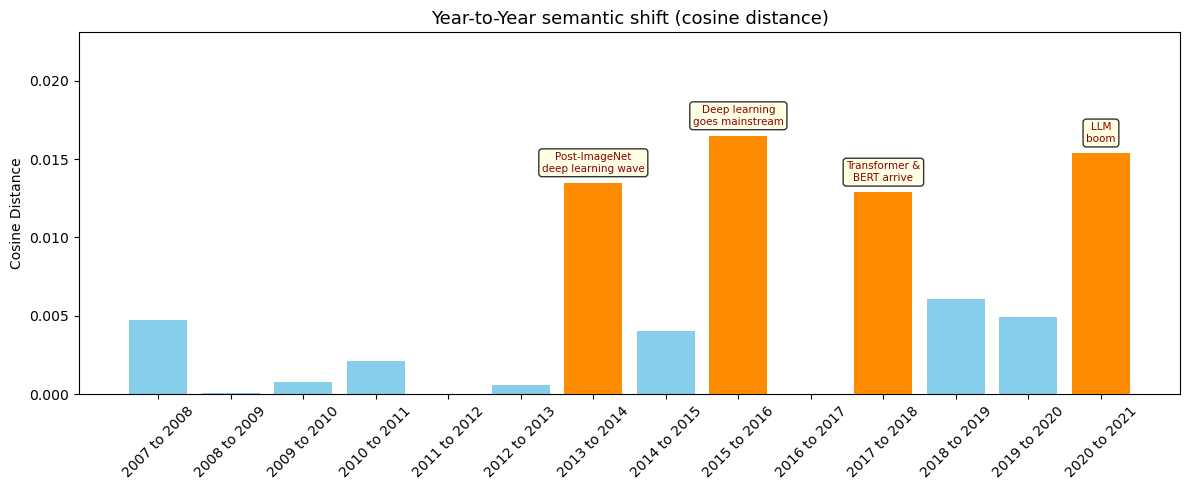

In [55]:
# Lastly, we will be plotting cosine distance plot
from sklearn.metrics.pairwise import cosine_similarity # for computing cosine similarity between vectors (1.0 = identical direction, 0.0 = completely different)

distances = [] # used to store results
for i in range(len(years) - 1): # since we are comparing pairs of consecutive years, we loop until the second-to-last year
    # v1 and v2 are the centroid positions of 2 consecutive years
    v1 = centroids.loc[years[i]].values.reshape(1, -1) # it gets the centroid vector for year i and reshapes it to be a 2D array with 1 row and 2 columns because cosine_similarity expects 2D arrays
    v2 = centroids.loc[years[i+1]].values.reshape(1, -1) # it gets the centroid vector for year i+1 and reshapes it similarly
    sim = cosine_similarity(v1, v2)[0][0] # it computes the cosine similarity between the two year centroids, which gives us a value, which if close to 1 means they are very similar, and if close to 0 means they are very different. We take [0][0] to extract a single number because cosine_similarity returns a 2D array of shape (1,1) in this case.
    distances.append({
        "transition": f"{years[i]} to {years[i+1]}",
        "cosine_distance": round(1 - sim, 4) # we convert similarity to distance by doing 1 - similarity, and round it to 4 decimal places for better readability
    })

dist_df = pd.DataFrame(distances) # this creates a new DataFrame from the list of distances, with 2 columns: transition and cosine_distance

fig, ax = plt.subplots(figsize=(12, 5)) # to create a new figure and axis for plotting

# Now for better visualization, we will be highlighting the big jumps in a different colour and annotating them with explanations of what 
# happened in the field during those years, which might have caused such a big shift in research focus.

# Key events to annotate
key_transitions = {
    "2013 to 2014": ("Post-ImageNet\ndeep learning wave", (0, 8)),
    "2015 to 2016": ("Deep learning\ngoes mainstream", (0, 8)),
    "2017 to 2018": ("Transformer &\nBERT arrive", (0, 8)),
    "2020 to 2021": ("LLM\nboom", (0, 8)),
}

# Colour bars used to highlight big ones in a different colour
colors = []
for t in dist_df["transition"]:
    if t in key_transitions:
        colors.append("darkorange") # darkorange for notable transitions
    else:
        colors.append("skyblue") # blue for normal transitions

ax.bar(dist_df["transition"], dist_df["cosine_distance"], color=colors) # it creates a bar plot with transitions on the x-axis and cosine distances on the y-axis, while using the colors we defined to highlight notable transitions in darkorange and normal transitions in sky blue
ax.set_ylim(0, max(dist_df["cosine_distance"]) * 1.4)  # 40% extra space at top for annotations

# Annotating the key bars
for _, row in dist_df.iterrows(): # we loop through each row in the dist_df DataFrame to check if the transition is one of the key transitions we want to annotate
    if row["transition"] in key_transitions: # if the transition is one of the key transitions we defined earlier, then we will annotate it
        label, offset = key_transitions[row["transition"]] # we get the label and offset for the annotation from the key_transitions dictionary
        ax.annotate(
            label,
            xy=(row["transition"], row["cosine_distance"]), # the point we are annotating is at the x position of the transition and y position of the cosine distance
            xytext=offset, # the text will be offset from the point by the specified amount in the key_transitions dictionary
            textcoords="offset points",
            ha="center",
            fontsize=7.5,
            color="darkred",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8) # adding a light yellow background box to the annotation text for better visibility
        )

# ax.bar(dist_df["transition"], dist_df["cosine_distance"], color="skyblue") # it creates a bar plot with transitions on the x-axis and cosine distances on the y-axis, while using a sky blue color for the bars
ax.set_title("Year-to-Year semantic shift (cosine distance)", fontsize=13) # now we set the title of the plot
ax.tick_params(axis='x', rotation=45) # we rotate the x-axis labels for better readability
ax.set_ylabel("Cosine Distance") # and set the y-axis label
plt.tight_layout() # just adjusting the layout to make sure everything fits well
plt.savefig("../figures/pca_yearly_cosine_distance_tfidf.png", dpi=150) # now saving the plot as a PNG file in the figures directory with a specified resolution
plt.show() # to display the plot
